In [28]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# Ruta de la carpeta que deseas explorar
carpeta_origen = 'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Acciones_reg/Acciones'

dataframes = []  # Lista para almacenar cada archivo

fecha_inicio = '20240401'  # Fecha de inicio
fecha_fin = '20240620'  # Fecha de fin

# Verifica la lista de archivos en la carpeta
print(f"Archivos en {carpeta_origen}:")
archivos = os.listdir(carpeta_origen)
print(archivos)

for archivo in archivos:
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv, ajusta según tus necesidades
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        print(f"Leyendo archivo: {ruta_archivo}")
        try:
            df = pd.read_csv(ruta_archivo, encoding='latin')
            
            # Obtén la fecha a partir del nombre del archivo
            fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')
            
            # Filtra por fechas
            if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%Y%m%d') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%Y%m%d'):
                df['Fecha'] = fecha_archivo  # Agrega la columna de fecha
                dataframes.append(df)
        except Exception as e:
            print(f"Error al leer el archivo {ruta_archivo}: {e}")

# Concatenar todos los dataframes
if dataframes:
    acciones = pd.concat(dataframes)
    print(acciones)
else:
    print("No se encontraron archivos dentro del rango de fechas especificado.")


Archivos en C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Acciones_reg/Acciones:
['20240401_accionesregulacion.csv', '20240402_accionesregulacion.csv', '20240403_accionesregulacion.csv', '20240404_accionesregulacion.csv', '20240405_accionesregulacion.csv', '20240406_accionesregulacion.csv', '20240407_accionesregulacion.csv', '20240408_accionesregulacion.csv', '20240409_accionesregulacion.csv', '20240410_accionesregulacion.csv', '20240411_accionesregulacion.csv', '20240412_accionesregulacion.csv', '20240413_accionesregulacion.csv', '20240414_accionesregulacion.csv', '20240415_accionesregulacion.csv', '20240416_accionesregulacion.csv', '20240417_accionesregulacion.csv', '20240418_accionesregulacion.csv', '20240419_accionesregulacion.csv', '20240420_accionesregulacion.csv', '20240421_accionesregulacion.csv', '20240422_accionesregulacion.csv', '20240423_accionesregulacion.csv', '20240424_accionesregulacion.csv', '20240425_accionesregulacion.csv', '20240426_ac

In [30]:
acciones

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
0,2024-04-01,2:12:11,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE105179""...",0,Motivo no definido
1,2024-04-01,2:13:26,0,0,NaN,0,20,Cambiar Conductor,jespinosa1,John Jairo Espinosa Santa,GMZ11,"<CambiarConductor ServicioConductor=""CE105179""...",0,Motivo no definido
2,2024-04-01,2:13:50,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107625""...",0,Motivo no definido
3,2024-04-01,2:14:06,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107138""...",0,Motivo no definido
4,2024-04-01,2:14:32,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107139""...",0,Motivo no definido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,2024-06-20,1:02:10,1030,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""17610"" Activar=""NO"" Sub...",0,Motivo no definido
1640,2024-06-20,1:02:19,1216,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""18300"" Activar=""NO"" Sub...",0,Motivo no definido
1641,2024-06-20,1:03:27,1413,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""10969"" Activar=""NO"" Sub...",0,Motivo no definido
1642,2024-06-20,1:03:45,1057,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""10139"" Activar=""NO"" Sub...",0,Motivo no definido


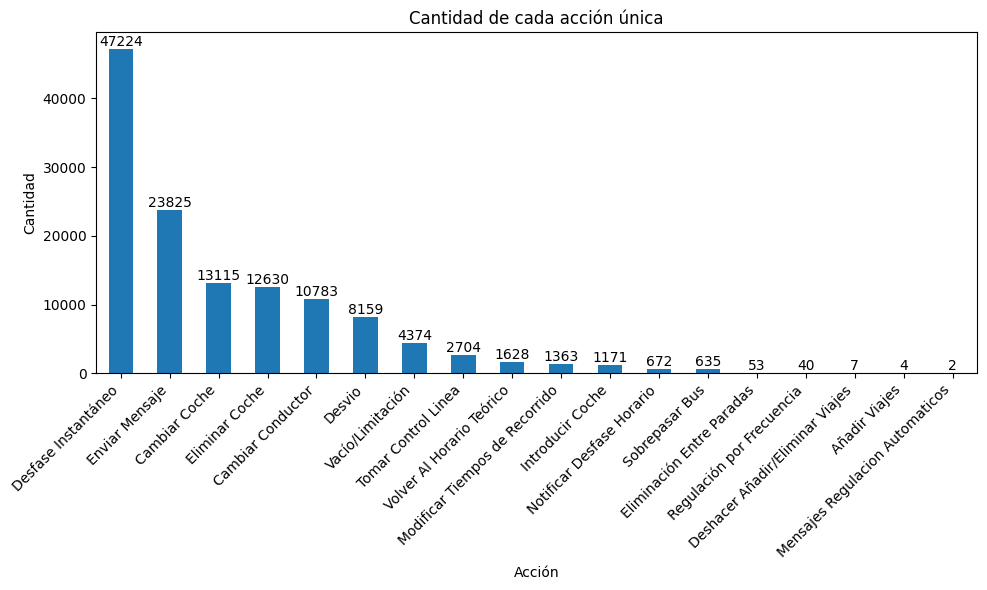

In [31]:
# Calcular las acciones únicas y su frecuencia
acciones_unicas = acciones['DescripcionAccion'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
acciones_unicas.plot(kind='bar')
plt.title('Cantidad de cada acción única')
plt.xlabel('Acción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

# Agregar etiquetas de datos
for i, v in enumerate(acciones_unicas):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [32]:
# Asegurarse de que la columna 'Fecha' sea de tipo datetime
acciones['Fecha'] = pd.to_datetime(acciones['Fecha'], errors='coerce')

# Eliminar filas con valores nulos en la columna 'Fecha'
acciones = acciones.dropna(subset=['Fecha'])

# Extraer el mes de la columna 'Fecha' y crear una nueva columna 'Mes'
acciones['Mes'] = acciones['Fecha'].dt.month

# Convertir la columna 'Mes' a tipo entero
acciones['Mes'] = acciones['Mes'].astype(int)


acciones

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,Mes
0,2024-04-01,2:12:11,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE105179""...",0,Motivo no definido,4
1,2024-04-01,2:13:26,0,0,NaN,0,20,Cambiar Conductor,jespinosa1,John Jairo Espinosa Santa,GMZ11,"<CambiarConductor ServicioConductor=""CE105179""...",0,Motivo no definido,4
2,2024-04-01,2:13:50,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107625""...",0,Motivo no definido,4
3,2024-04-01,2:14:06,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107138""...",0,Motivo no definido,4
4,2024-04-01,2:14:32,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107139""...",0,Motivo no definido,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,2024-06-20,1:02:10,1030,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""17610"" Activar=""NO"" Sub...",0,Motivo no definido,6
1640,2024-06-20,1:02:19,1216,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""18300"" Activar=""NO"" Sub...",0,Motivo no definido,6
1641,2024-06-20,1:03:27,1413,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""10969"" Activar=""NO"" Sub...",0,Motivo no definido,6
1642,2024-06-20,1:03:45,1057,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""10139"" Activar=""NO"" Sub...",0,Motivo no definido,6


In [33]:
# Convertir la columna 'Instante' a cadena de caracteres (str)
acciones['Instante'] = acciones['Instante'].astype(str)

# Extraer los dos primeros dígitos antes del primer ":"
acciones['Franja'] = acciones['Instante'].str.split(':').str[0]

# Mostrar los primeros registros para verificar
print(acciones[['Instante', 'Franja']])

acciones

     Instante Franja
0     2:12:11      2
1     2:13:26      2
2     2:13:50      2
3     2:14:06      2
4     2:14:32      2
...       ...    ...
1639  1:02:10      1
1640  1:02:19      1
1641  1:03:27      1
1642  1:03:45      1
1643  1:03:57      1

[128389 rows x 2 columns]


,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,Mes,Franja
0,2024-04-01,2:12:11,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE105179""...",0,Motivo no definido,4,2
1,2024-04-01,2:13:26,0,0,NaN,0,20,Cambiar Conductor,jespinosa1,John Jairo Espinosa Santa,GMZ11,"<CambiarConductor ServicioConductor=""CE105179""...",0,Motivo no definido,4,2
2,2024-04-01,2:13:50,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107625""...",0,Motivo no definido,4,2
3,2024-04-01,2:14:06,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107138""...",0,Motivo no definido,4,2
4,2024-04-01,2:14:32,0,0,NaN,0,20,Cambiar Conductor,VSC,Sandra Carolina Valeriano,GMZ01,"<CambiarConductor ServicioConductor=""CE107139""...",0,Motivo no definido,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,2024-06-20,1:02:10,1030,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""17610"" Activar=""NO"" Sub...",0,Motivo no definido,6,1
1640,2024-06-20,1:02:19,1216,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""18300"" Activar=""NO"" Sub...",0,Motivo no definido,6,1
1641,2024-06-20,1:03:27,1413,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""10969"" Activar=""NO"" Sub...",0,Motivo no definido,6,1
1642,2024-06-20,1:03:45,1057,0,NaN,0,22,Desvio,YIHA,Yerly Irene Hernandez Ariza,TMZ53,"<ActivarDesvio Desvio=""10139"" Activar=""NO"" Sub...",0,Motivo no definido,6,1


C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15288\927198674.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mes', y='DescripcionAccion', data=acciones_por_mes, palette='viridis')
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15288\927198674.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Franja', y='DescripcionAccion', data=acciones_por_franja, palette='viridis')


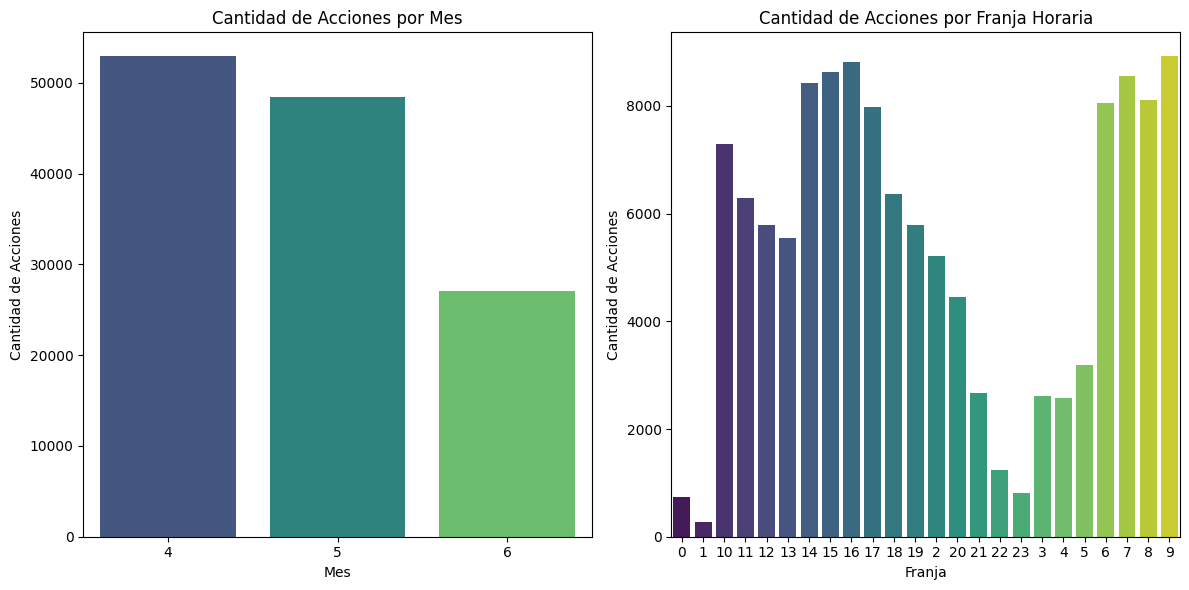

In [34]:
# Calcular la cantidad de acciones por Mes y Franja
acciones_por_mes = acciones.groupby('Mes')['DescripcionAccion'].count().reset_index()
acciones_por_franja = acciones.groupby('Franja')['DescripcionAccion'].count().reset_index()

# Crear las gráficas por separado
plt.figure(figsize=(12, 6))

# Gráfico por Mes
plt.subplot(1, 2, 1)
sns.barplot(x='Mes', y='DescripcionAccion', data=acciones_por_mes, palette='viridis')
plt.title('Cantidad de Acciones por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Acciones')

# Gráfico por Franja
plt.subplot(1, 2, 2)
sns.barplot(x='Franja', y='DescripcionAccion', data=acciones_por_franja, palette='viridis')
plt.title('Cantidad de Acciones por Franja Horaria')
plt.xlabel('Franja')
plt.ylabel('Cantidad de Acciones')

# Ajustar espaciado entre gráficos
plt.tight_layout()

# Mostrar las gráficas
plt.show()

In [35]:
# Crear una copia del DataFrame original
ar_1 = acciones.copy()

# Filtrar la columna 'DescripcionAccion' por el valor 'Vacío/Limitación'
ar_1 = ar_1[ar_1['DescripcionAccion'].str.contains('Vacío/Limitación')]

# Eliminar las columnas 'Columna1' y 'Columna2'
columnas_a_eliminar = ['NumBus','DescripcionAccion','Usuario']
ar_1 = ar_1.drop(columns=columnas_a_eliminar)

ar_1

,Fecha,Instante,Linea,Coche,CodigoBus,Accion,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,Mes,Franja
161,2024-04-01,6:00:33,1435,9,Z50-7103,27,Norberto Niño Rodriguez,GMT01,"<VacioLimitacion Accion=""Vacio"" Desde=""PA58325...",7,Bus Retrasado,4,6
233,2024-04-01,6:33:22,1435,3,Z50-7092,27,Norberto Niño Rodriguez,GMT01,"<VacioLimitacion Accion=""Vacio"" Desde=""PA52357...",7,Bus Retrasado,4,6
240,2024-04-01,6:38:43,1091,32,Z50-4192,27,Laura Marcela Vargas Gutierrez,GMZ06,"<VacioLimitacion Accion=""Desvio"" Desde=""PA5623...",10,Accidente,4,6
438,2024-04-01,7:30:42,1103,16,Z50-4511,27,Rosa Tellez,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""PA57392...",5,Congestión vehicular,4,7
439,2024-04-01,7:31:36,1103,16,Z50-4511,27,Rosa Tellez,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""PA57392...",5,Congestión vehicular,4,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,2024-06-20,20:24:35,1435,7,Z50-7079,27,Maicol Alexander Pita Blanco,TMT28,"<VacioLimitacion Accion=""Vacio"" Desde=""PA53086...",5,Congestión vehicular,6,20
1542,2024-06-20,20:24:59,1435,7,Z50-7079,27,Maicol Alexander Pita Blanco,TMT28,"<VacioLimitacion Accion=""Vacio"" Desde=""PA52999...",5,Congestión vehicular,6,20
1543,2024-06-20,20:27:56,1062,1,Z50-4173,27,Esteban Camilo Medina,ETZ10,"<VacioLimitacion Accion=""Vacio"" Desde=""PA50984...",5,Congestión vehicular,6,20
1574,2024-06-20,21:04:29,1185,43,Z50-7023,27,Paula Katherine Cantor Salamanca,TMZ53,"<VacioLimitacion Accion=""Desvio"" Desde=""PA5374...",5,Congestión vehicular,6,21


In [36]:
# Definir las condiciones y los valores correspondientes
condiciones = [
    ar_1['Parametros'].str.contains('="Vacio"', regex=False),
    ar_1['Parametros'].str.contains('="Desvio"', regex=False),
    ar_1['Parametros'].str.contains('="Limitar"', regex=False)
]
valores = [1, 2, 3]

# Utilizar np.select() para asignar los valores basados en las condiciones
ar_1['Accion/Vacio'] = np.select(condiciones, valores, default=0)  # Si no se cumple ninguna condición, se asigna 0

ar_1

,Fecha,Instante,Linea,Coche,CodigoBus,Accion,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,Mes,Franja,Accion/Vacio
161,2024-04-01,6:00:33,1435,9,Z50-7103,27,Norberto Niño Rodriguez,GMT01,"<VacioLimitacion Accion=""Vacio"" Desde=""PA58325...",7,Bus Retrasado,4,6,1
233,2024-04-01,6:33:22,1435,3,Z50-7092,27,Norberto Niño Rodriguez,GMT01,"<VacioLimitacion Accion=""Vacio"" Desde=""PA52357...",7,Bus Retrasado,4,6,1
240,2024-04-01,6:38:43,1091,32,Z50-4192,27,Laura Marcela Vargas Gutierrez,GMZ06,"<VacioLimitacion Accion=""Desvio"" Desde=""PA5623...",10,Accidente,4,6,2
438,2024-04-01,7:30:42,1103,16,Z50-4511,27,Rosa Tellez,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""PA57392...",5,Congestión vehicular,4,7,1
439,2024-04-01,7:31:36,1103,16,Z50-4511,27,Rosa Tellez,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""PA57392...",5,Congestión vehicular,4,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,2024-06-20,20:24:35,1435,7,Z50-7079,27,Maicol Alexander Pita Blanco,TMT28,"<VacioLimitacion Accion=""Vacio"" Desde=""PA53086...",5,Congestión vehicular,6,20,1
1542,2024-06-20,20:24:59,1435,7,Z50-7079,27,Maicol Alexander Pita Blanco,TMT28,"<VacioLimitacion Accion=""Vacio"" Desde=""PA52999...",5,Congestión vehicular,6,20,1
1543,2024-06-20,20:27:56,1062,1,Z50-4173,27,Esteban Camilo Medina,ETZ10,"<VacioLimitacion Accion=""Vacio"" Desde=""PA50984...",5,Congestión vehicular,6,20,1
1574,2024-06-20,21:04:29,1185,43,Z50-7023,27,Paula Katherine Cantor Salamanca,TMZ53,"<VacioLimitacion Accion=""Desvio"" Desde=""PA5374...",5,Congestión vehicular,6,21,2


In [37]:
# Actualizar la columna 'Accion/Vacio' para que sea 1 si es diferente de cero y 0 si es igual a cero
ar_1['Aplicada'] = ar_1['Accion/Vacio'].apply(lambda x: 1 if x != 0 else 0)

ar_1

,Fecha,Instante,Linea,Coche,CodigoBus,Accion,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,Mes,Franja,Accion/Vacio,Aplicada
161,2024-04-01,6:00:33,1435,9,Z50-7103,27,Norberto Niño Rodriguez,GMT01,"<VacioLimitacion Accion=""Vacio"" Desde=""PA58325...",7,Bus Retrasado,4,6,1,1
233,2024-04-01,6:33:22,1435,3,Z50-7092,27,Norberto Niño Rodriguez,GMT01,"<VacioLimitacion Accion=""Vacio"" Desde=""PA52357...",7,Bus Retrasado,4,6,1,1
240,2024-04-01,6:38:43,1091,32,Z50-4192,27,Laura Marcela Vargas Gutierrez,GMZ06,"<VacioLimitacion Accion=""Desvio"" Desde=""PA5623...",10,Accidente,4,6,2,1
438,2024-04-01,7:30:42,1103,16,Z50-4511,27,Rosa Tellez,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""PA57392...",5,Congestión vehicular,4,7,1,1
439,2024-04-01,7:31:36,1103,16,Z50-4511,27,Rosa Tellez,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""PA57392...",5,Congestión vehicular,4,7,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,2024-06-20,20:24:35,1435,7,Z50-7079,27,Maicol Alexander Pita Blanco,TMT28,"<VacioLimitacion Accion=""Vacio"" Desde=""PA53086...",5,Congestión vehicular,6,20,1,1
1542,2024-06-20,20:24:59,1435,7,Z50-7079,27,Maicol Alexander Pita Blanco,TMT28,"<VacioLimitacion Accion=""Vacio"" Desde=""PA52999...",5,Congestión vehicular,6,20,1,1
1543,2024-06-20,20:27:56,1062,1,Z50-4173,27,Esteban Camilo Medina,ETZ10,"<VacioLimitacion Accion=""Vacio"" Desde=""PA50984...",5,Congestión vehicular,6,20,1,1
1574,2024-06-20,21:04:29,1185,43,Z50-7023,27,Paula Katherine Cantor Salamanca,TMZ53,"<VacioLimitacion Accion=""Desvio"" Desde=""PA5374...",5,Congestión vehicular,6,21,2,1


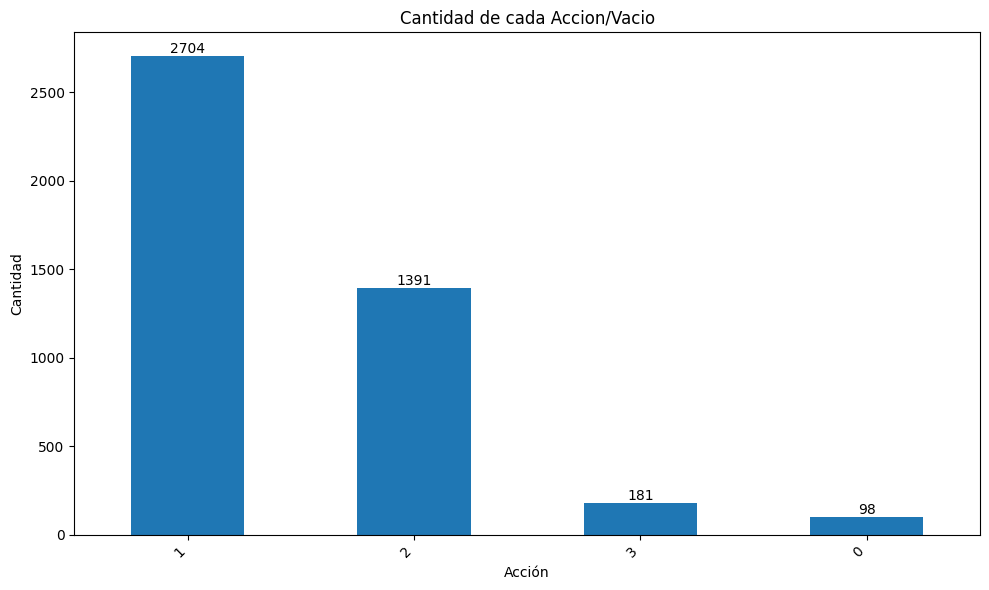

In [38]:
# Calcular  Accion/Vacio
acciones_unicas = ar_1['Accion/Vacio'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
acciones_unicas.plot(kind='bar')
plt.title('Cantidad de cada Accion/Vacio')
plt.xlabel('Acción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

# Agregar etiquetas de datos
for i, v in enumerate(acciones_unicas):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

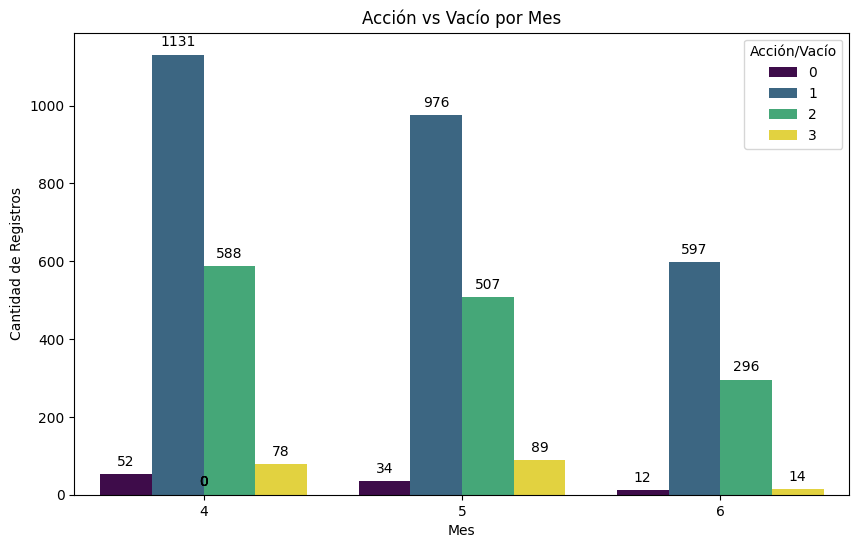

In [39]:
accion_vacio_por_mes = ar_1.groupby(['Mes', 'Accion/Vacio']).size().reset_index(name='Counts')

# Gráfico de barras utilizando seaborn
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Mes', y='Counts', hue='Accion/Vacio', data=accion_vacio_por_mes, palette='viridis')
plt.title('Acción vs Vacío por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Registros')
plt.legend(title='Acción/Vacío', loc='upper right')

# Añadir etiquetas de datos encima de cada barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

# Mostrar la gráfica
plt.show()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15288\3989300649.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=categorias_ordenadas, y=accion_vacio_counts[categorias_ordenadas], palette='viridis')


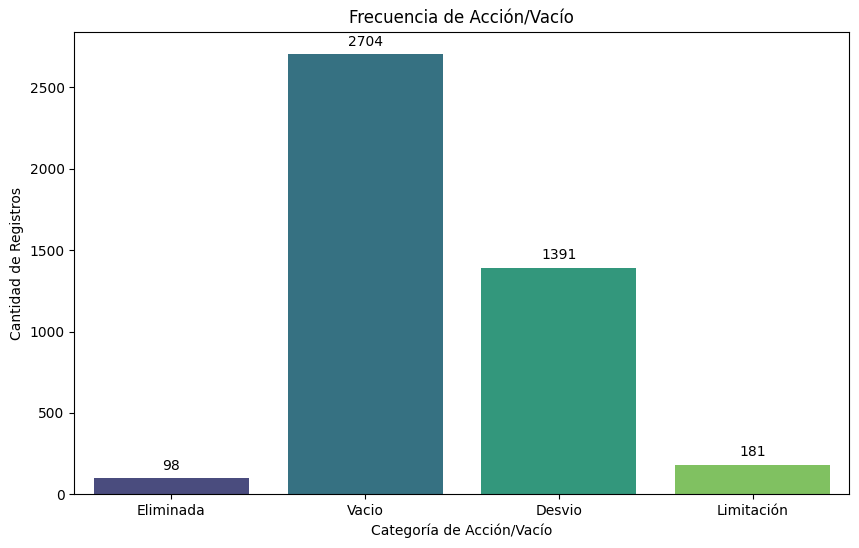

In [40]:
# Mapear los valores numéricos a categorías específicas
ar_1['Accion/Vacio'] = ar_1['Accion/Vacio'].map({
    0: 'Eliminada',
    1: 'Vacio',
    2: 'Desvio',
    3: 'Limitación'
})

# Calcular la frecuencia de cada categoría
accion_vacio_counts = ar_1['Accion/Vacio'].value_counts()

# Ordenar las categorías en el orden deseado para el gráfico
categorias_ordenadas = ['Eliminada', 'Vacio', 'Desvio', 'Limitación']

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=categorias_ordenadas, y=accion_vacio_counts[categorias_ordenadas], palette='viridis')
plt.title('Frecuencia de Acción/Vacío')
plt.xlabel('Categoría de Acción/Vacío')
plt.ylabel('Cantidad de Registros')

# Añadir etiquetas de datos encima de cada barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points')

# Mostrar el gráfico
plt.show()

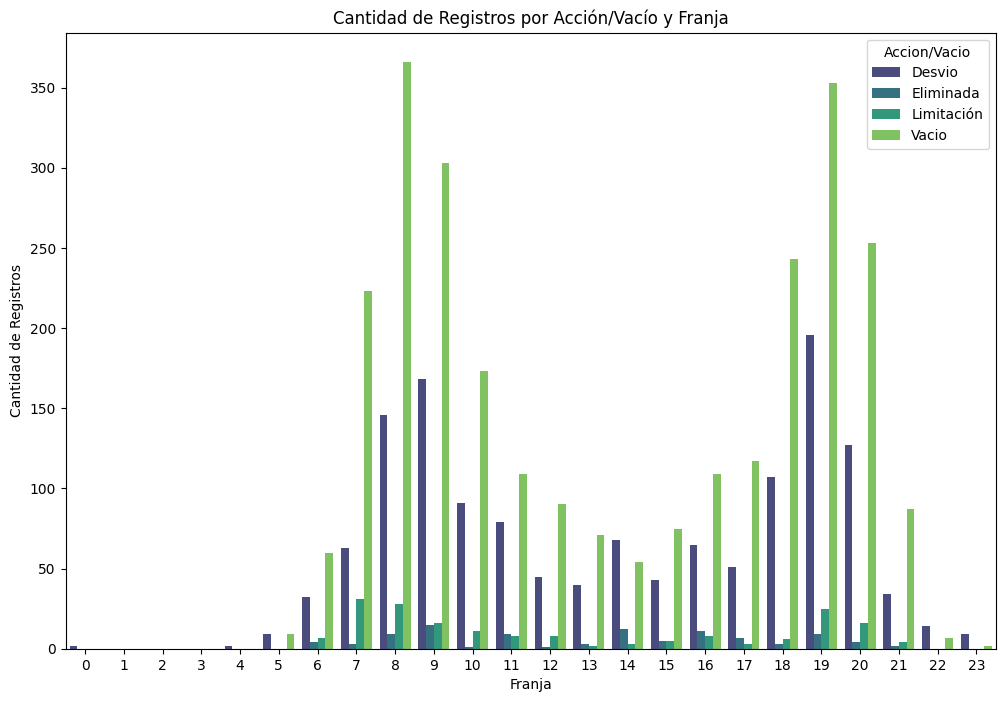

In [41]:
# Calcular la frecuencia de cada combinación de 'Accion/Vacio' y 'Franja'
accion_vacio_franja_counts = ar_1.groupby(['Accion/Vacio', 'Franja']).size().reset_index(name='counts')

# Ordenar las categorías en 'Accion/Vacio' para el gráfico
categorias_ordenadas = ['Eliminada', 'Vacio', 'Desvio', 'Limitación']

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
barplot = sns.barplot(data=accion_vacio_franja_counts, x='Franja', y='counts', hue='Accion/Vacio', palette='viridis', order=range(0, 24))
plt.title('Cantidad de Registros por Acción/Vacío y Franja')
plt.xlabel('Franja')
plt.ylabel('Cantidad de Registros')

# Mostrar el gráfico
plt.legend(title='Accion/Vacio')
plt.show()